In [1]:
%reset -f
from xmlrpc.client import Error
import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize as scp
import uproot
import matplotlib
from holoviews.plotting.bokeh.styles import font_size
from networkx import convert_node_labels_to_integers
from pandas.compat.numpy.function import validate_max
from vispy.gloo.gl import GL_UNSIGNED_SHORT_4_4_4_4

font = {'weight' : 'bold',
        'size'   : 15}

matplotlib.rc('font', **font)
### Opticks Nexus Analysis

import h5py
from pandas import read_hdf
import seaborn as sns
import scipy.special as misc
from scipy.special import loggamma
from matplotlib.colors import LogNorm
from matplotlib.colors import Normalize
import fireducks.pandas as pd
import os
import pickle    
isSafeFiles=False
Reflections=True
ImagePath="/media/argon/5TB2_rooks/CRAB/Images"
if(Reflections):
    SavePath=ImagePath+"/With_Reflections"
else:
    SavePath=ImagePath+"/No_Reflections"

In [2]:
def factorial(x):
    return np.math.factorial(np.uint64(x))

def Gauss1D(x,Ampl,mean,sigma):
    return Ampl*np.exp(-(x-mean)**2/(2*(sigma)**2)) 

def Poisson1D(x,gamma):
    #vfactorial=np.vectorize(factorial)
    return (gamma**x)*np.exp(-gamma)/(misc.factorial(x))

## https://stackoverflow.com/questions/53308919/overflow-error-in-poisson-distribution-implementation
## Solves overflow issue
def log_Likelihood(x,gamma):
    return (np.log(gamma)*x - loggamma(x+1)-gamma)
    #return (np.log(gamma)*x - np.log(1/(misc.factorial(x)))-gamma)


In [3]:
def Gauss1DSkew(x,Ampl,mean,sigma,a,offset):
    return Ampl*np.exp(-(x-mean)**2/(2*(sigma+a*(x-mean))**2))+offset

def FitHist1D(hist,ax,label,clr,ap,width=3,linstyle="-"):
    ## Locate Min and Max
    MinAndMaxMask=(hist[0]>=(np.mean(hist[0])*0.1)) & (hist[0]<=np.max(hist[0])*0.9)
    
    initials=(np.max(hist[0]),np.mean(hist[1][:-1][MinAndMaxMask]),np.std(hist[1][:-1][MinAndMaxMask]),0,0)
    #initials=(np.max(hist[0]),0,np.std(hist[1][:-1][MinAndMaxMask]),0,0)
    print(f"Initials {initials}")
    fit=scp.curve_fit(Gauss1DSkew,hist[1][:-1],hist[0],p0=initials,maxfev=5000)
    String_=label+r'$\bar{X}$'+f"={round(fit[0][1],2)}," + r'$\sigma$' +f"= {abs(round(fit[0][2],2))}"
    #ax.text(np.min(data),fit[0][0],s=String_,color=clr)
    if(ax):
        ax.plot(hist[1][:-1],Gauss1DSkew(hist[1][:-1],*fit[0]),label=String_,color=clr,linestyle=linstyle,alpha=ap,linewidth=width)
    FitValues={"Amp":round(fit[0][0],2),"u":round(fit[0][1],2),"sigma":abs(round(fit[0][2],2)),"offset":round(fit[0][3],2)}
    print(FitValues)
    return FitValues

def exp(x,A1,t1,A2,t2):
    return A1*np.exp(-x/t1)+A2*np.exp(-x/t2)

def FitExp(hist,ax,label,clr,ap,width=3,linstyle="-"):
    initials=(np.max(hist[0]),4.5,np.max(hist[0])/2,100)
    fit=scp.curve_fit(exp,hist[1][:-1],hist[0],p0=initials)
    String_=label+f"t1={abs(round(fit[0][1],2))},t2={abs(round(fit[0][3],2))}"
    #ax.text(np.min(data),fit[0][0],s=String_,color=clr)
    ax.plot(hist[1][:-1],exp(hist[1][:-1],*fit[0]),label=String_,color=clr,alpha=ap,linewidth=width,linestyle=linstyle)    
    

In [4]:
wavelength=lambda E:1239.8/E # ev to nm 
GetEnergy=lambda w:1239.8/w # ev to nm 
def ListofFiles(path,extension="h5"):
    filelist=[]
    for root, dirs, files in os.walk(path):
        for file in files:
            if file.endswith(extension):
                filelist.append(os.path.join(root,file))
    return filelist

def GetInfo(filePath,FileLimit=-1,isCombined=True,EventLimit=-1,SkipKeys=None,SkipSubKeys=None):
    All={}
    subVal={}
    subsubVal={}
    if(filePath.endswith("h5")):
        f=h5py.File(filePath,"r")
        
        for folder in f:
            subVal={}
            for table in f[folder]:
                subsubVal={}
                if(SkipKeys!=None and table in SkipKeys ):
                    continue
                    
                for field in f[folder][table].dtype.fields.keys():
                    if(field in SkipSubKeys):
                        continue 
                    subsubVal[field]=f[folder][table][field]
                if(subsubVal):    
                    subVal[table]=subsubVal
            All[folder]=subVal
        f.close()
    else:
        Files=ListofFiles(filePath)
        Counter=0
        Combined={}
        SingleFile={}
        for file in Files:
            print(file)
            f=h5py.File(file,"r")
            if(not isCombined):
                SingleFile={}
            for folder in f:
                subVal={}
                for table in f[folder]:
                    subsubVal={}
                    if(SkipKeys!=None and table in SkipKeys ):
                        continue
                    for field in f[folder][table].dtype.fields.keys():
                        #if no value then ignore it
                        
                        if(field in SkipSubKeys):
                            continue
                        subsubVal[field]=np.array(f[folder][table][field])
    
                        if(subsubVal[field].size == 0):
                            continue
                        if(Combined):
                            MaxEventID=0
                            if(field=="event_id" and Counter>0):
                                #print(f"{table}/{field}")
                                MaxEventID=np.max(Combined[table][field])+1
                                #print(Combined[table][field])
                                subsubVal[field]=MaxEventID+subsubVal[field]
                                #print(MaxEventID)
                                #print(subsubVal[field])
                            Combined[table][field]=np.hstack((Combined[table][field],subsubVal[field]))
                    if(subsubVal):        
                        subVal[table]=subsubVal
                if(not isCombined and (subVal)):    
                    SingleFile[folder]=subVal
                else:
                    if(Counter==0 and (subVal)):
                        print("Setting Combined Value")
                        Combined=subVal
            f.close()
            if(not isCombined):
                All[Counter]=SingleFile
            if(FileLimit==Counter):
                break   
            Counter+=1
        if(isCombined):
            All=Combined
    return All

## For Merging the slurm files if they are not merged
def MergerSlurm(SlurmDic,limit=-1):
    Combined={}
    for key in SlurmDic.keys():
        if key == 0:
            #print(f"Handling First Key {key}")
            Combined=SlurmDic[key]
        else:
            #print(f"Handling SubKeys {key}")
            for subkey in SlurmDic[key].keys():
                for subsubkey in SlurmDic[key][subkey].keys():
                    for subsubsubkey in SlurmDic[key][subkey][subsubkey].keys():
                        Combined[subkey][subsubkey][subsubsubkey]=np.append(Combined[subkey][subsubkey][subsubsubkey],SlurmDic[key][subkey][subsubkey][subsubsubkey])
        if(limit == key):
            break
    del SlurmDic        
    return Combined          
def PickleITDump(data,fileName):
    with open(fileName,'wb') as f:
        pickle.dump(data,f)
        
def PickleITRead(fileName):
    with open(fileName,'rb') as f:
        data=pickle.load(f)
    return data


In [5]:
p1="/home/argon/Projects/Ilker/NewNexus/out/t.h5"

In [6]:
data=vv=GetInfo(p1,SkipKeys=["sns_positions","sns_response","particles","hits","configuration","Timing"],SkipSubKeys=["hit_id","polx","poly","polz","momx","momy","momz","name"])

In [7]:
vv={}
G4HitsSlurm={}

In [8]:
## With Reflections

G4Folder="/media/argon/5TB2_rooks/CRAB/Test/May_30_2025/10bar_G4/Reflections/"
G4Folder=""
MC=data["MC"]
if("Opticks_Hits" in data["MC"]):
    vv=data["MC"]["Opticks_Hits"]
        
if("Geant4_Optical_Hits" in data["MC"]):
    G4HitsSlurm=data["MC"]["Geant4_Optical_Hits"]
    
if(G4Folder):
    G4HitsSlurm=PickleITRead(G4Folder+"G4.p")['GEANT4_Optical_Hits']
    MC['GEANT4_Optical_Hits']=G4HitsSlurm

In [9]:
if("DEBUG" in vv):
    Opticks=DEBUG['opticks_photon_info']
G4={}
if ("particles" in MC):
    G4=MC["particles"]
    Mask=G4["particle_name"]==b'opticalphoton'
InitialPhotonInfo={}
if ("Timing" in MC):
    InitialPhotonInfo=MC["Timing"]
G4Hits={}
OpticksHits={}
G4S1TimeMask=np.array([])
G4S2TimeMask=np.array([])
OpticksS2TimeMask=np.array([])
OpticksS1TimeMask=np.array([])

theMainDic={}
Time=1500
if("GEANT4_Optical_Hits" in MC):
    theMainDic=MC
    G4Hits=theMainDic["GEANT4_Optical_Hits"]

    G4S1TimeMask=theMainDic["GEANT4_Optical_Hits"]["time"]<Time
    G4S2TimeMask=theMainDic["GEANT4_Optical_Hits"]["time"]>Time
    
if("Opticks_Hits" in MC):
    OpticksHits=MC['Opticks_Hits']
    OpticksS2TimeMask=MC['Opticks_Hits']["time"]>Time
    OpticksS1TimeMask=MC['Opticks_Hits']["time"]<Time



In [10]:
if("DEBUG" in vv):
    wMax=np.max(np.array([np.max(wavelength(G4["kin_energy"][Mask]*1e6)),np.max(Opticks["wavelength"])]))
    wMin=np.min(np.array([np.min(wavelength(G4["kin_energy"][Mask]*1e6)),np.min(Opticks["wavelength"])]))
    
    bins_=np.linspace(wMin,wMax,30)
    plt.title("Wavelength Comparison",fontweight='bold',fontsize=35)
    h1=plt.hist(Opticks["wavelength"],bins=bins_,alpha=1,label="Opticks",color="red",edgecolor="red")
    FitHist1D(h1,plt,"","red")
    
    h2=plt.hist(wavelength(G4["kin_energy"][Mask]*1e6),bins=bins_,alpha=0.5,label="G4",hatch='//',color="green",edgecolor="green")
    FitHist1D(h2,plt,"","green")
    
    plt.xlabel("wavelength (nm)")
    plt.legend(fontsize=20)
    if(isSafeFiles):
        plt.savefig(f"{SavePath}/S2_Timing_Absorbed.png")
    del h1,h2

In [11]:
if("particle_name" in G4):
    Mask=G4["particle_name"]==b'opticalphoton'
    G4PhotonTimeInitial=G4["initial_t"][Mask]
    G4PhotonTimeFinal=G4["final_t"][Mask]
if("DEBUG" in vv):
    OpticksPhotonTime=Opticks["time"]


In [12]:
if("DEBUG" in vv):
    wMax=np.max(np.array([np.max(G4PhotonTimeFinal),np.max(OpticksPhotonTime)]))
    wMin=np.min(np.array([np.min(G4PhotonTimeFinal),np.min(OpticksPhotonTime)]))
    bins_=np.linspace(wMin,wMax,30)
    
    plt.figure(figsize=(12,8),dpi=300)
    plt.title("S2 Photons",fontweight='bold',fontsize=35)
    #plt.hist(timeDifference,bins=bins_,label="G4")
    h1=plt.hist(OpticksPhotonTime,bins=bins_,alpha=0.3,label="Opticks",color="red",edgecolor="red",histtype="step",fill=True)
    FitHist1D(h1,plt,"","red")
    h2=plt.hist(G4PhotonTimeFinal,bins=bins_,alpha=0.3,label="G4",histtype="step",fill=True,color="green",edgecolor="green")
    FitHist1D(h2,plt,"","green")
    plt.ticklabel_format(axis='y',style='sci',scilimits=(0,0),useMathText=True)
    #_=plt.hist(G4PhotonTimeInitial,bins=200,alpha=0.5,label="final",hatch="//")
    plt.legend(fontsize=20)
    plt.xlabel("time(ns)",fontsize=25)
    print(f"max {wMax} and min {wMin}")
    if(isSafeFiles):
        plt.savefig(f"{SavePath}/S2_Hit_Wavelength_Absorbed.png")
    del h1,h2

In [13]:
def PlotFit1D(xval,yval,ax,title,type="Gauss",bin=100,colors=["blue","orange"],labels=["Opticks","Geant4"],axislabels=["Frequency","Wavelength (nm)"],isSubplot=True,Plot="both",opacity=[1,1],fontsize=30,width=3,fill=False):
    wMax=0
    wMin=0
    if(xval.size!=0 and yval.size!=0):
        wMax=np.max(np.array([np.max(xval),np.max(yval)]))
        wMin=np.min(np.array([np.min(xval),np.min(yval)]))
    elif(xval.size==0 and yval.size!=0):
        wMax=np.max(yval)
        wMin=np.min(yval)
    elif(xval.size!=0 and yval.size==0):
        wMax=np.max(xval)
        wMin=np.min(xval)
    bins_=np.linspace(wMin,wMax,bin)
    if(isSubplot):
        ax.set_title(title,fontweight='bold',fontsize=fontsize+20)
    else:
        ax.title(title,fontweight='bold',fontsize=fontsize+20)
  
    if( yval.size!=0):
        h2=ax.hist(yval,bins=bins_,alpha=opacity[1],label=labels[1],linestyle="-",linewidth=width,histtype="step",fill=fill,color=colors[1],edgecolor=colors[1])
        if(Plot=="both"):
            FitHist1D(h2,ax,"",colors[1],ap=1,width=width) if (type=="Gauss") else FitExp(h2,ax,"",colors[1],ap=1,width=width) 
    if( xval.size!=0):    
        h1=ax.hist(xval,bins=bins_,alpha=opacity[0],label=labels[0],linestyle="--",color=colors[0],linewidth=width,edgecolor=colors[0],histtype="step",fill=fill)
        if(Plot=="both"):
            #FitHist1D(h1,ax,"",colors[0],0.5) if (type=="Gauss") else FitExp(h1,ax,"",colors[0],0.5) 
            FitHist1D(h1,ax,"",colors[0],ap=1,width=width)  if (type=="Gauss") else FitExp(h1,ax,"",colors[0],ap=1,width=width) 
   
    if(isSubplot):
         ax.set_xlabel(axislabels[1],fontsize=fontsize+10)
         ax.set_ylabel(axislabels[0],fontsize=fontsize+10) 
    else:
         ax.xlabel(axislabels[1],fontsize=fontsize)
         ax.ylabel(axislabels[0],fontsize=fontsize)
    ax.tick_params(axis='both', which='major', labelsize=fontsize+10)    
   
    ax.legend(fontsize=fontsize)
    ax.yaxis.get_offset_text().set_size(fontsize+10) 
    ax.ticklabel_format(axis='y',style='sci',scilimits=(0,0),useMathText=True)
    #ax.tick_params(axis='both', labelsize=fontsize+10)
    
    

Initials (1488.0, 172.99595144805124, 9.33759581698958, 0, 0)
{'Amp': 1467.66, 'u': 171.61, 'sigma': 5.45, 'offset': 0.03}
Initials (1522.0, 173.01396665461675, 9.061707787400778, 0, 0)
{'Amp': 1477.47, 'u': 171.56, 'sigma': 5.51, 'offset': 0.04}


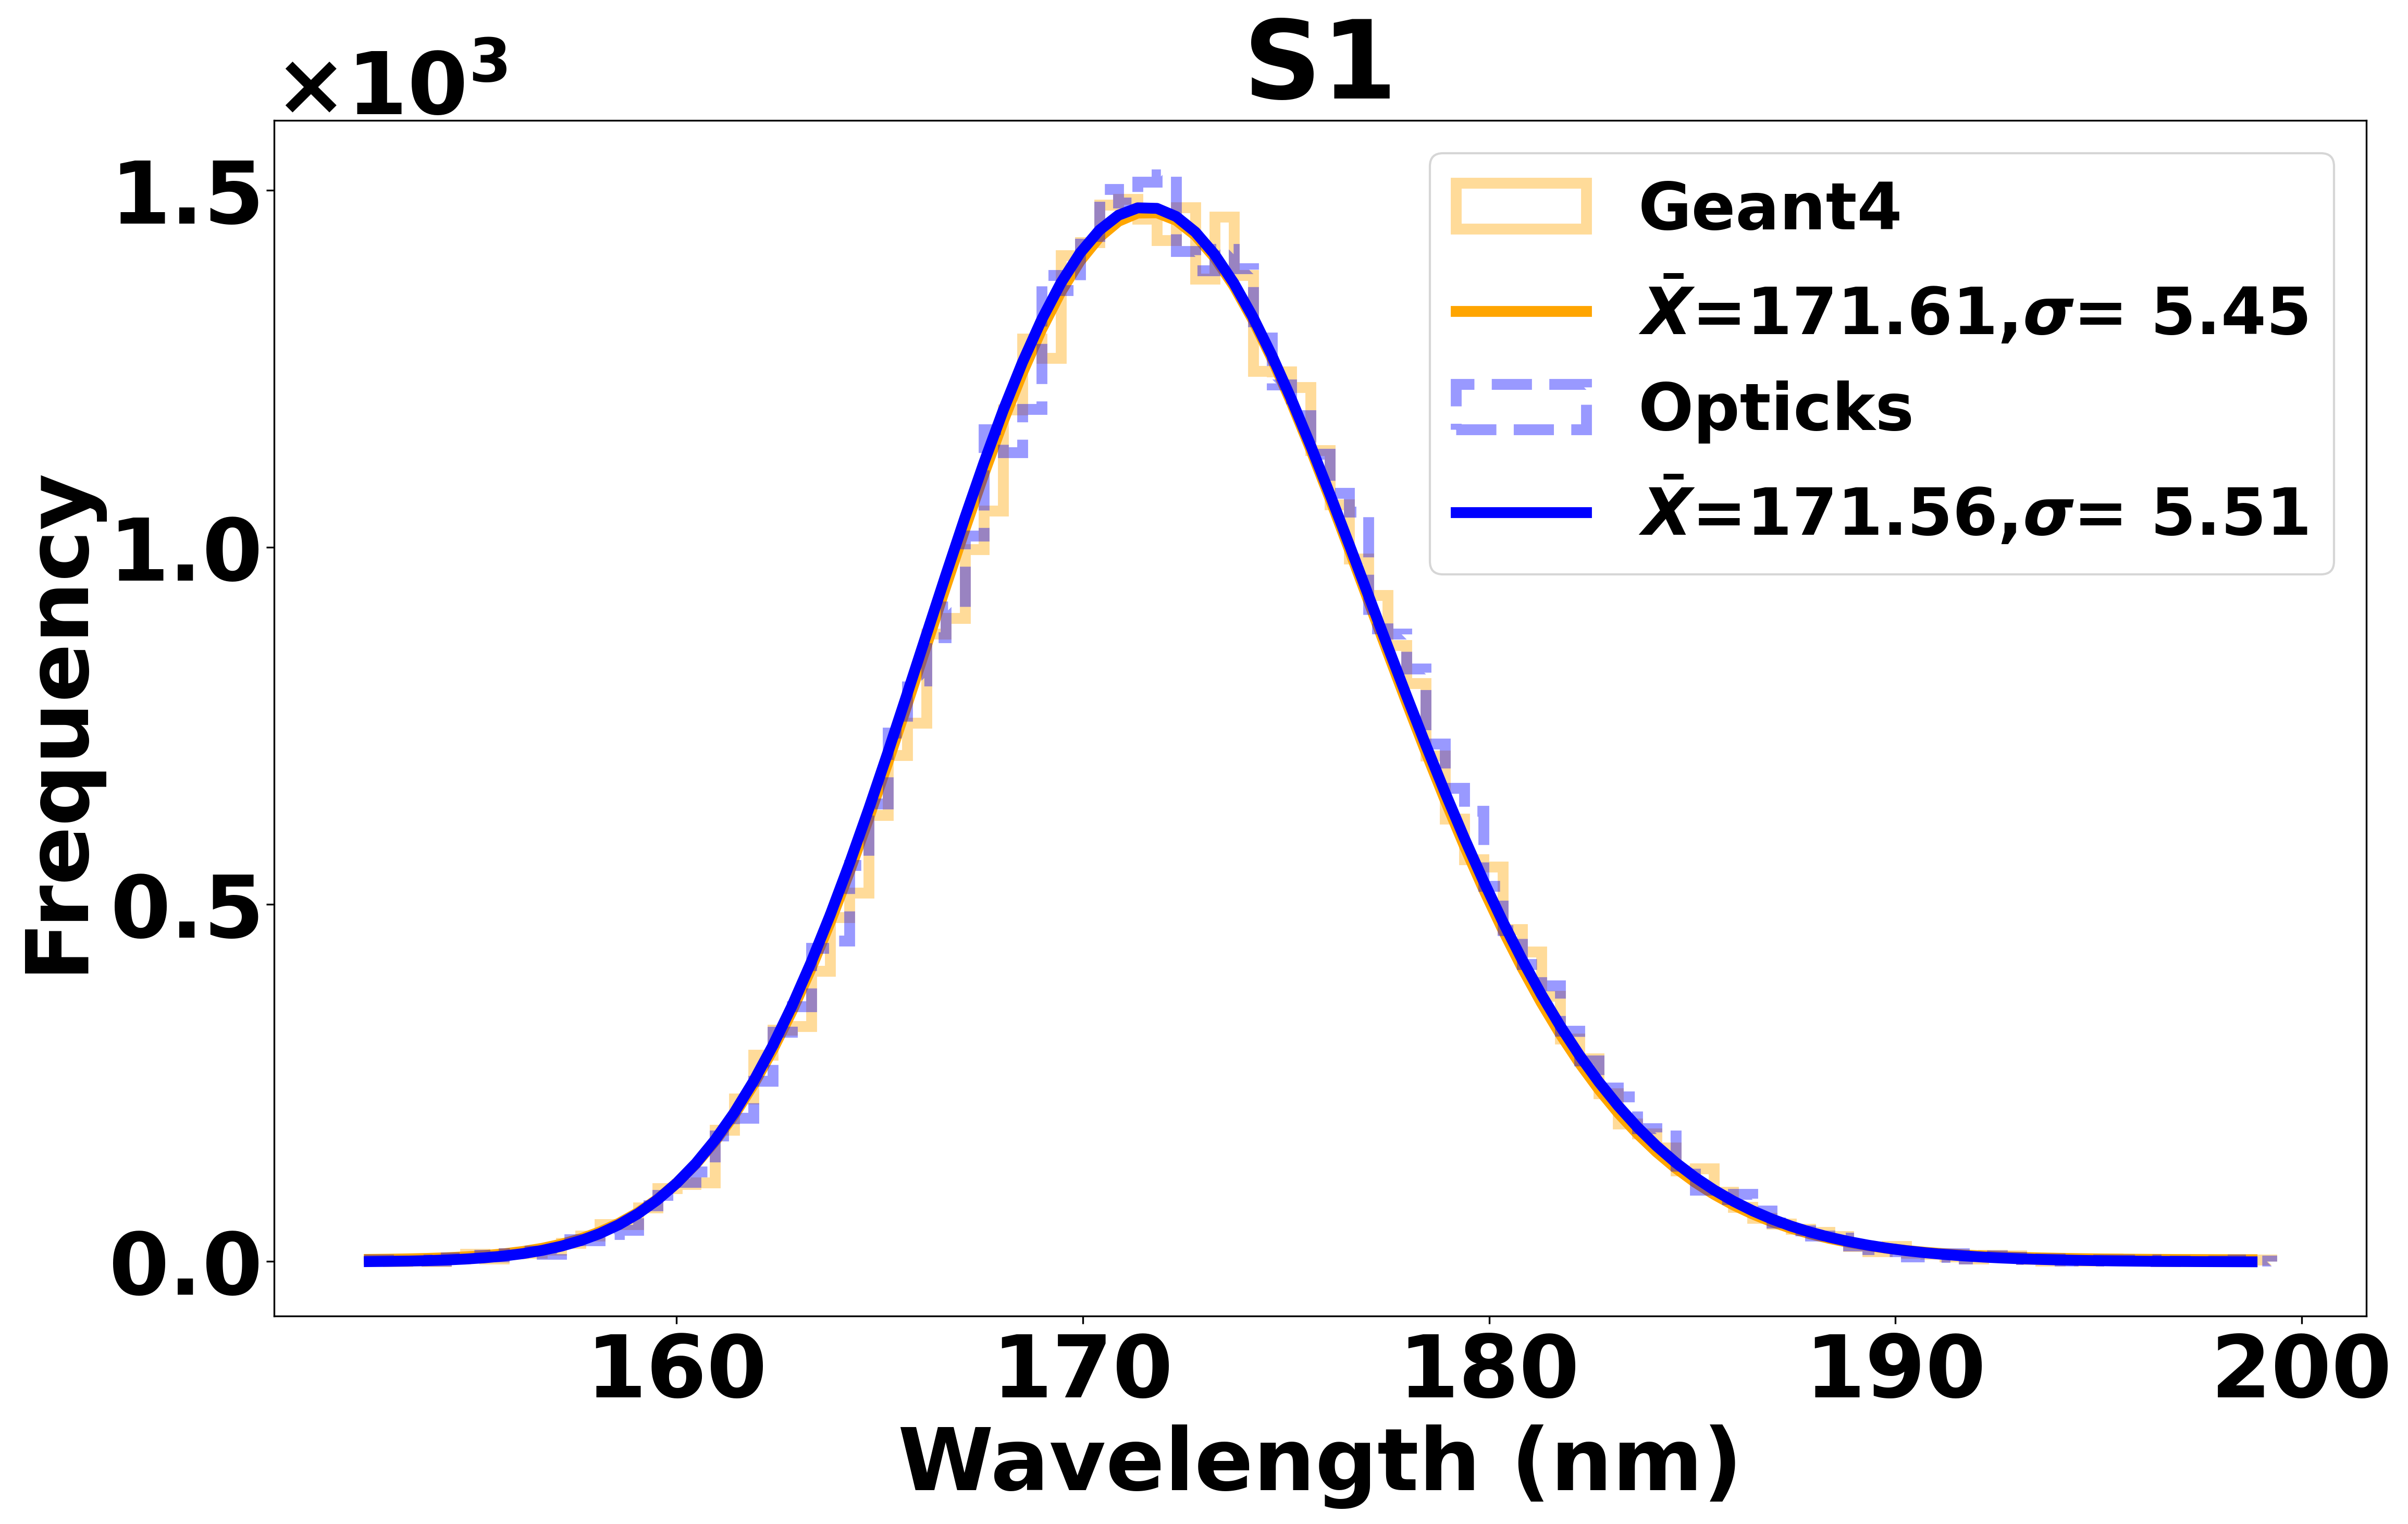

In [14]:
fig,ax=plt.subplots(1,2,figsize=(30,10),dpi=300)
G4S1WavelengthHit=np.array([])
OpticksS1WavelengthHit=np.array([])

if(G4Hits):
    G4S1WavelengthHit = G4Hits["wavelength"][G4S1TimeMask]
## Opticks Values are first for S1

if(OpticksHits):
    OpticksS1WavelengthHit = OpticksHits["wavelength"][OpticksS1TimeMask]
PlotFit1D(OpticksS1WavelengthHit,G4S1WavelengthHit,ax[0],title="S1",bin=100,opacity=[0.4,0.4],width=5,fill=False)
    
## Opticks Values are first for S1
fig.tight_layout()
plt.xticks(fontsize=45)
plt.yticks(fontsize=45)
#ax[0].semilogy()
#ax[1].semilogy()
ax[1].set_visible(False)

if(isSafeFiles):
    fig.savefig(f"{SavePath}/S1_S2_Detected_Wavelength.png")


In [15]:
G4S1TimeHit=np.array([])
G4S2TimeHit=np.array([])
OpticksS1TimeHit=np.array([])
OpticksS2TimeHit=np.array([])

if(G4Hits):
    G4S1TimeHit=G4Hits["time"][G4S1TimeMask]
    G4S2TimeHit = G4Hits["time"][G4S2TimeMask]

if(OpticksHits):
    OpticksS1TimeHit=OpticksHits["time"][OpticksS1TimeMask]
    OpticksS2TimeHit = OpticksHits["time"][OpticksS2TimeMask]

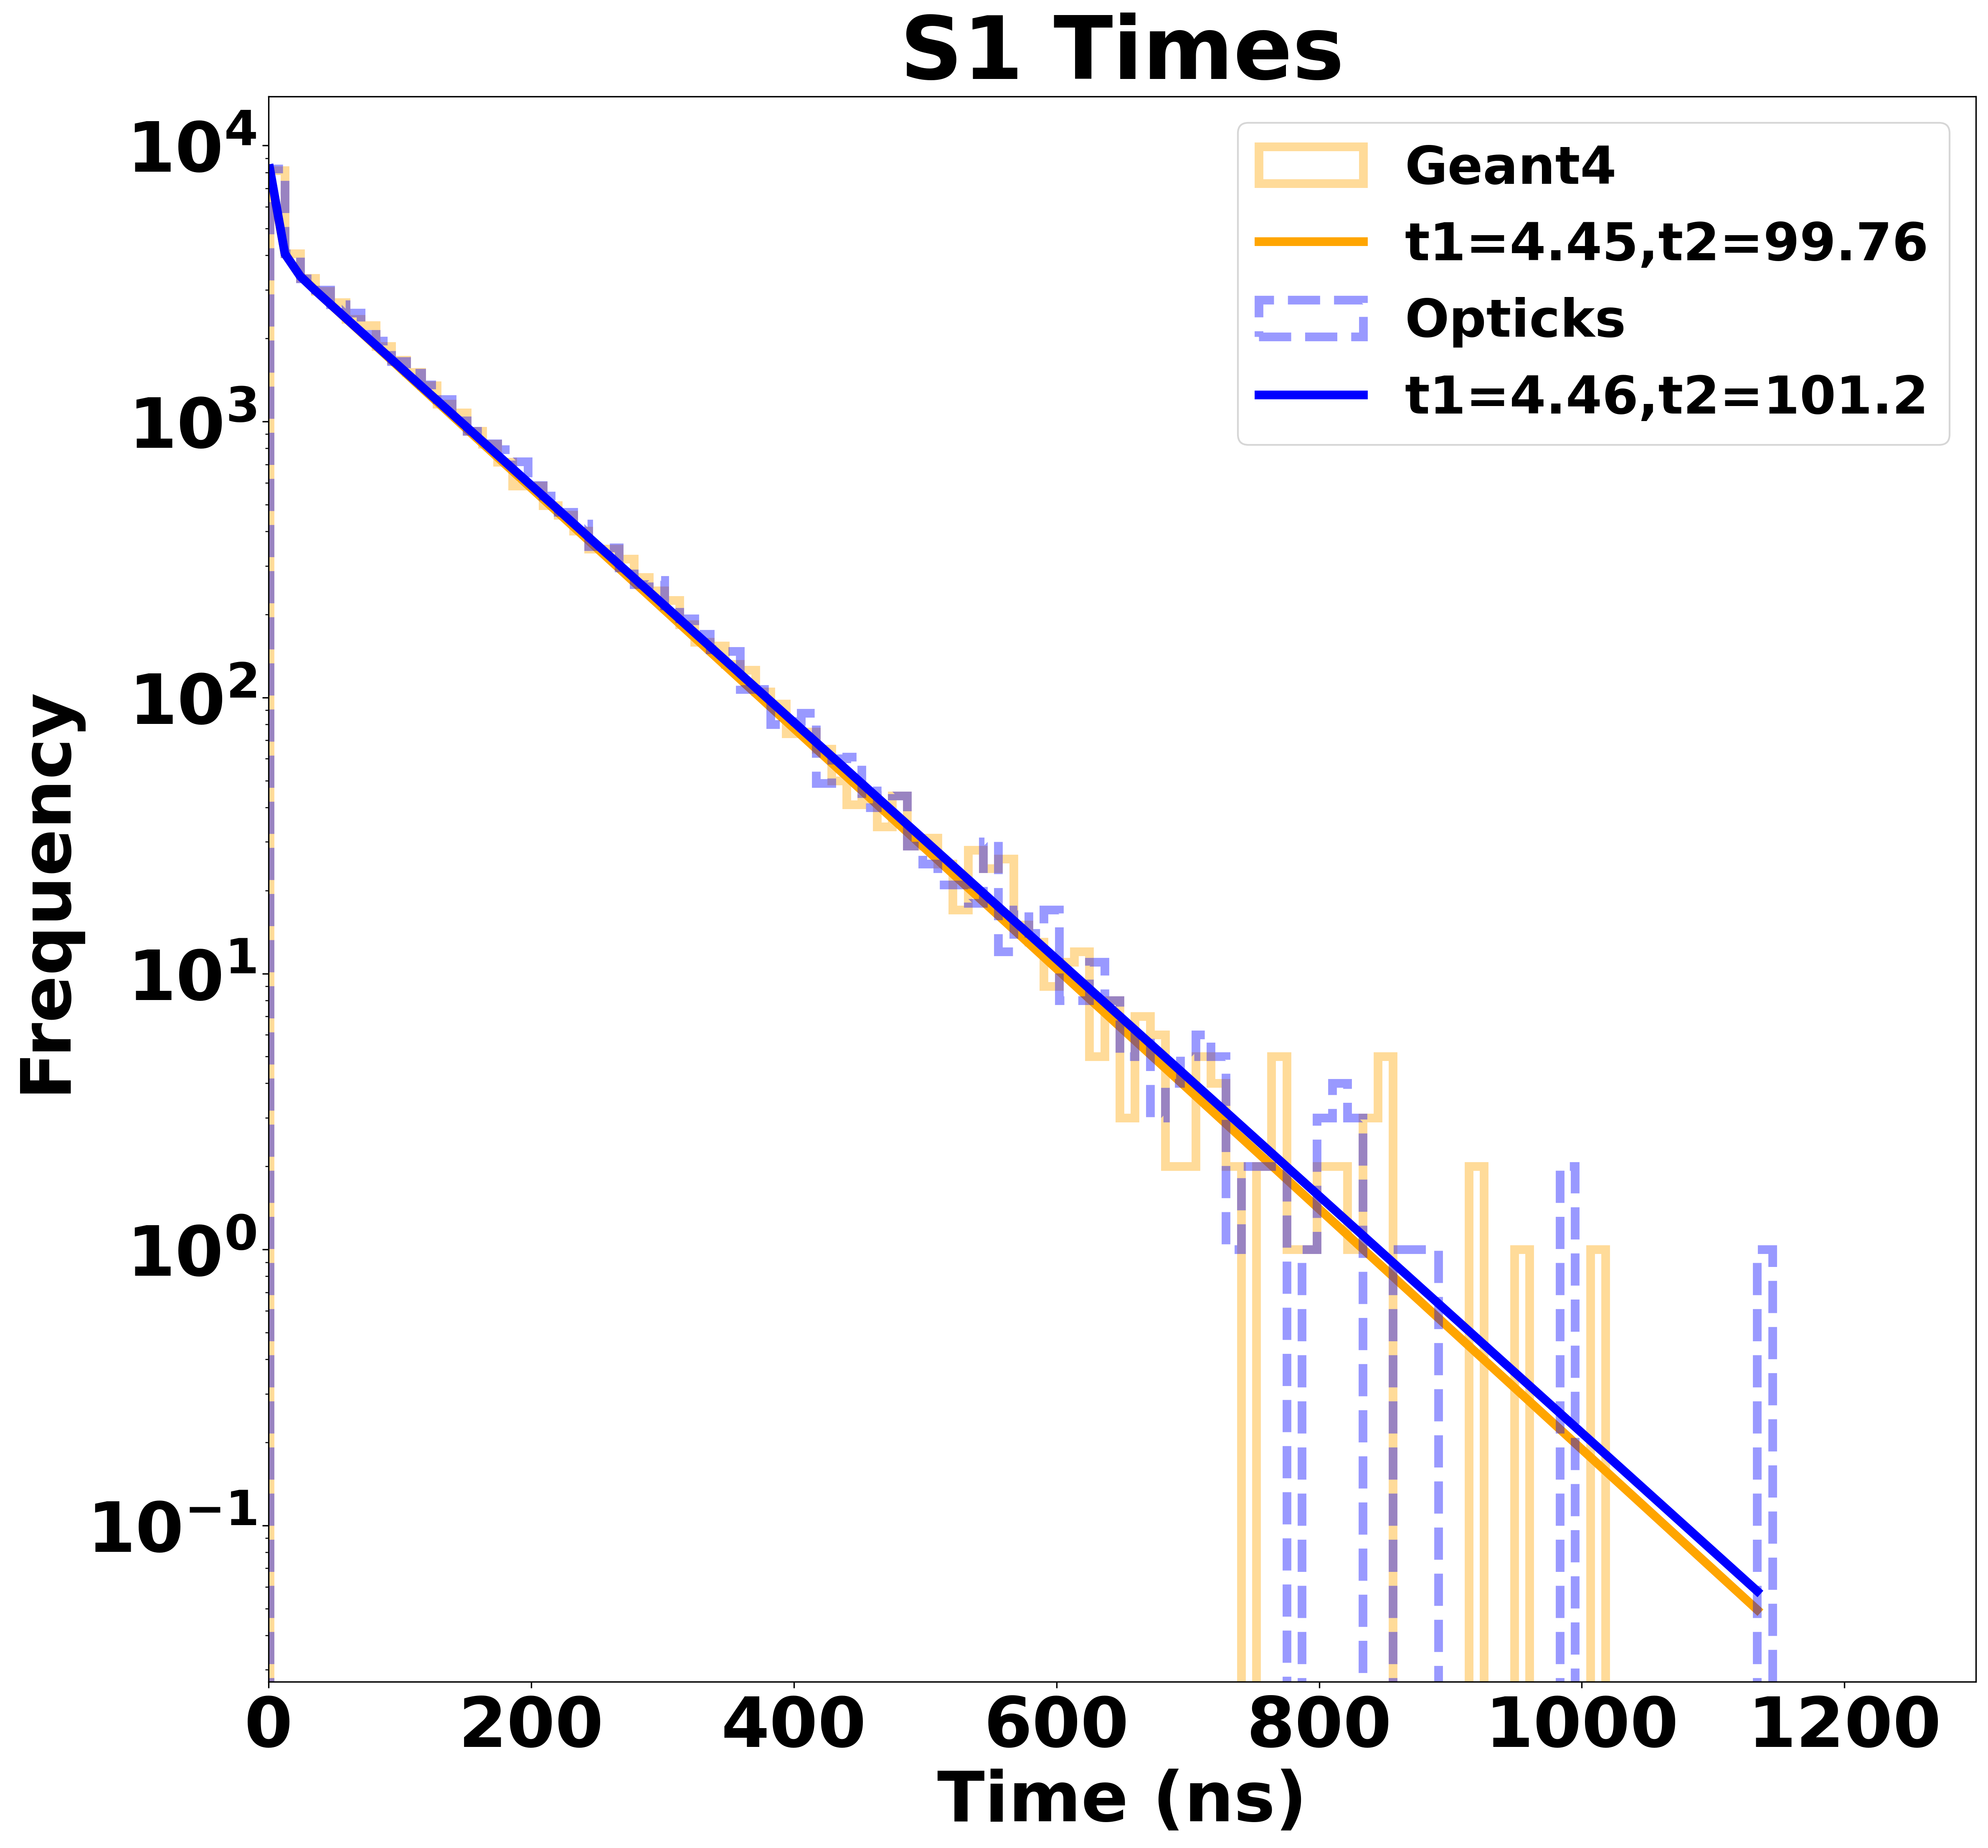

In [16]:
fig,ax=plt.subplots(1,2,figsize=(30,15),dpi=300)
S1Lables=["Frequency","Time (ns)"]
t_label="Time ("+r'$\mu$'+"s)"
S2Lables=["Frequency",t_label]


## Opticks Values are first for S1
PlotFit1D(OpticksS1TimeHit,G4S1TimeHit,ax[0],type="Exp",title="S1 Times",axislabels=S1Lables,bin=100
          ,opacity=[0.4,0.4],width=5,fill=False)

ax[0].set_xlim(0,1300)
## Opticks Values are first for S1

#ax[1].set_xlim(90,115)
fig.tight_layout()
ax[0].semilogy()
ax[1].set_visible(False)
#ax[1].semilogy()
if(isSafeFiles):
    fig.savefig(f"{SavePath}/S1_S2_Detected_Times.png")


In [17]:

if("polx" in G4Hits):
    G4Pol=np.array([[0],[0],[0]])
    OPol=np.array([[0],[0],[0]])
    if(G4Hits):
        G4Pol=np.array([G4Hits["polx"][G4S2TimeMask],G4Hits["poly"][G4S2TimeMask],G4Hits["polz"][G4S2TimeMask]])
    if(OpticksHits):
        OPol=np.array([OpticksHits["polx"][OpticksS2TimeMask],OpticksHits["poly"][OpticksS2TimeMask],OpticksHits["polz"][OpticksS2TimeMask]])
    fig,ax=plt.subplots(1,3,figsize=(25,10),dpi=300)
    S1Lables=["Frequency","Time (ns)"]
    S2Lables=["Frequency","Time (us)"]
    
    ## Opticks Values are first for S1
    PlotFit1D(G4Pol[0],OPol[0],ax[0],type="Gauss",title="Pol X",axislabels=["Frequency","Polarization in X"],bin=100,Plot="")
    
    
    ## Opticks Values are first for S1
    PlotFit1D(G4Pol[1],OPol[1],ax[1],type="Gauss",title="Pol Y",axislabels=["Frequency","Polarization in Y"],bin=100,Plot="")
    
    ## Opticks Values are first for S1
    PlotFit1D(G4Pol[2],OPol[2],ax[2],type="Gauss",title="Pol Z",axislabels=["Frequency","Polarization in Z"],bin=100,Plot="")
    
    if(isSafeFiles):
        fig.savefig(f"{SavePath}/Polarizations.png")


In [18]:
if("momx" in G4Hits):
    MomMagnitude=np.sqrt(G4Hits["momx"][G4S2TimeMask]**2+G4Hits["momy"][G4S2TimeMask]**2+G4Hits["momz"][G4S2TimeMask]**2)
    G4Mom=[G4Hits["momx"][G4S2TimeMask]/MomMagnitude,G4Hits["momy"][G4S2TimeMask]/MomMagnitude,G4Hits["momz"][G4S2TimeMask]/MomMagnitude]
    OMom=[OpticksHits["momx"][OpticksS2TimeMask],OpticksHits["momy"][OpticksS2TimeMask],OpticksHits["momz"][OpticksS2TimeMask]]
    fig,ax=plt.subplots(1,3,figsize=(25,10),dpi=300)
    
    
    ## Opticks Values are first for S1
    PlotFit1D(G4Mom[0],OMom[0],ax[0],type="Gauss",title="Direction of Mom in X",axislabels=["Frequency","Momentum in X"],bin=100,Plot="")
    
    
    ## Opticks Values are first for S1
    PlotFit1D(G4Mom[1],OMom[1],ax[1],type="Gauss",title="Direction of Mom in Y",axislabels=["Frequency","Momentum in Y"],bin=100,Plot="")
    
    ## Opticks Values are first for S1
    PlotFit1D(G4Mom[2],OMom[2],ax[2],type="Gauss",title="Direction of Mom in Z",axislabels=["Frequency","Momentum in Z"],bin=100,Plot="")
    
    if(isSafeFiles):
        fig.savefig(f"{SavePath}/Momentum.png")


In [19]:
#%reset -f

In [20]:
## Opticks
OpticsS1PMTMask=np.array([])
OpticksS1CamMask=np.array([])
OpticsS2PMTMask=np.array([])
OpticksS2CamMask=np.array([])
if(OpticksHits):
    OpticsS1PMTMask=(OpticksHits['z'][OpticksS1TimeMask]<100)    ##PMT
    OpticksS1CamMask=(OpticksHits['z'][OpticksS1TimeMask] > 200)
    ## Opticks
    OpticsS2PMTMask = (OpticksHits['z'][OpticksS2TimeMask] < 100)  ##PMT
    OpticksS2CamMask = (OpticksHits['z'][OpticksS2TimeMask] > 200)  ##Camera
    bnd = [np.unique(OpticksHits['boundary'][OpticksS2TimeMask][OpticsS2PMTMask]), np.unique(OpticksHits['boundary'][OpticksS2TimeMask][OpticksS2CamMask])]

    if (len(bnd[0]) > 1 or len(bnd[1]) > 1):
        print("Boundary issue ")
        bnd = [bnd[0], bnd[1]]
Geant4S2PMTMask=np.array([])
Geant4S2CamMask=np.array([])
Geant4S1PMTMask=np.array([])
Geant4S1CamMask=np.array([])        

if(G4Hits):
    if("name" in G4Hits):
        ## Geant4
        Geant4S2PMTMask = G4Hits['name'][G4S2TimeMask] == b'PMTWindow'  ##PMT
        Geant4S2CamMask = G4Hits['name'][G4S2TimeMask] == b'camWindow'  ##Camera
        
        Geant4S1PMTMask = G4Hits['name'][G4S1TimeMask] == b'PMTWindow'  ##PMT
        Geant4S1CamMask = G4Hits['name'][G4S1TimeMask] == b'camWindow'  ##Camera##Camera
    else:
        Geant4S1PMTMask=(G4Hits['z'][G4S1TimeMask]<100)    ##PMT
        Geant4S1CamMask=(G4Hits['z'][G4S1TimeMask] > 200)
        ## Opticks
        Geant4S2PMTMask = (G4Hits['z'][G4S2TimeMask] < 100)  ##PMT
        Geant4S2CamMask = (G4Hits['z'][G4S2TimeMask] > 200)  ##Camera

In [21]:
import matplotlib.pyplot as plt

def Plot2D_JointPlot(valO,ValG4,FileName,Title,Binsize=200,histBin=500,isPlottext=False,isHistType="numpy"):

    maXX=np.max(np.array([np.max(ValG4[0]),np.max(valO[0])]))
    miNX=np.min(np.array([np.min(ValG4[0]),np.min(valO[0])]))
    lins1X=np.linspace(miNX,maXX,Binsize)
    
    maXY=np.max(np.array([np.max(ValG4[1]),np.max(valO[1])]))
    miNY=np.min(np.array([np.min(ValG4[1]),np.min(valO[1])]))
    lins1Y=np.linspace(miNY,maXY,Binsize)
    
    G4Dict={"x(mm)":ValG4[0],"y(mm)":ValG4[1]}
    OpticksDict={"x(mm)":valO[0],"y(mm)":valO[1]}
    plt.figure(figsize=(15,15),dpi=300)
    g=sns.jointplot(data=G4Dict,x="x(mm)", y="y(mm)", kind='hist',bins=[lins1X,lins1Y],marginal_kws={"bins":lins1X,"kde":True},cmap="viridis",color="green",height=10,cbar=True,cbar_kws={"use_gridspec":False, "location":"top","aspect":50,"fraction":0.016,"pad":0,"aspect":50});
    #plt.hist2d(ValG4[0], ValG4[1], bins=[lins1X,lins1Y], cmap="viridis",norm=LogNorm());
    x=0
    y=0
    fitx=0
    fity=0
    g.ax_joint.tick_params(axis='both', which='major', labelsize=25) 
    g.ax_joint.set_xlabel("x (mm)",fontsize=25)
    g.ax_joint.set_ylabel("y (mm)",fontsize=25)
    if(isPlottext):
        binX=np.linspace(np.min(ValG4[0]),np.max(ValG4[0]),histBin)
        binY=np.linspace(np.min(ValG4[1]),np.max(ValG4[1]),histBin)
        if(isHistType=="numpy"):
            x=np.histogram(ValG4[0], bins=binX)
            y=np.histogram(ValG4[1], bins=binY)
            fitx=FitHist1D(x,None,"x","blue",0.5)
            fity=FitHist1D(y,None,"y","red",0.5)
        else:
            x=np.histogram(ValG4[0], bins=binX)
            y=np.histogram(ValG4[1], bins=binY)
            x=plt.hist(ValG4[0], bins=lins1X)
            y=np.histogram(ValG4[1], bins=lins1Y)
            fitx=FitHist1D(x,plt,"x","blue",0.5)
            fity=FitHist1D(y,plt,"y","red",0.5)
            plt.xlim(-5,5)
        g.ax_marg_x.axvspan(fitx["u"] - fitx["sigma"],fitx["u"] + fitx["sigma"], color='gray', alpha=0.35)

        g.ax_marg_y.axhspan(fity["u"] - fity["sigma"], fity["u"] + fity["sigma"], color='gray', alpha=0.35)
        g.refline(x=fitx["u"], y=fity["u"], color='green', ls='--',alpha=0.4)
        ## Place the Values to Cells
        ax_marg_x = g.ax_marg_x
        Ydata= g.ax_marg_x.get_yticks()
        Xdata= g.ax_marg_y.get_yticks()
        ax_marg_y = g.ax_marg_y
        ## Place  the text to Marginal X axis
        #print(x_mean,x_std)
        XMean=fitx["u"]
        YMean=fity["u"]
        Xsig=fitx["sigma"]
        Ysig=fity["sigma"]
        labelX_str=r'$\bar{X}$' + f" = {str(XMean)}, " + r'$\sigma_{X}$'+f" = {str(Xsig)}"
        labelY_str=r'$\bar{Y}$' + f" = {str(YMean)}, \n " + r'$\sigma_{Y}$'+f" = {str(Ysig)}"
        ## Mean and STD for X and Y
        ax_marg_x.text(XMean+ 2*Xsig, np.mean(Ydata), labelX_str, fontsize=20)
        ax_marg_y.text( np.mean(Xdata),YMean + 2*Ysig, labelY_str, fontsize=20)
        
    
    #g.plot_joint(sns.kdeplot, color="red", zorder=0, alpha=0.3,levels=6)
    #g.plot_marginals(sns.rugplot,  color="red", height=+.02, clip_on=False)
    plt.suptitle(Title[1],fontweight="bold",ha="right",fontsize=25)
    if (isSafeFiles):
        plt.savefig(f"{SavePath}/{FileName[1]}.png")
        
    g=sns.jointplot(data=OpticksDict,x="x(mm)",y= "y(mm)" ,kind='hist',cmap="viridis",bins=[lins1X,lins1Y],marginal_kws={"bins":Binsize,"kde":True},color="red",height=10,cbar=True,cbar_kws={"use_gridspec":True,"fraction":0.016,"pad":0,"location":"top","aspect":50});
    g.ax_joint.tick_params(axis='both', which='major', labelsize=25)    
    g.ax_joint.set_xlabel("x (mm)",fontsize=25)
    g.ax_joint.set_ylabel("y (mm)",fontsize=25)
    #g.plot_joint(sns.kdeplot,  color="green",alpha=0.3, zorder=0, levels=6)
    #g.plot_marginals(sns.rugplot,  color="green", height=+.02, clip_on=False)
    #plt.hist2d(valO[0], valO[1], bins=[lins1X,lins1Y], cmap="viridis",norm=LogNorm());
    x=0
    y=0
    fitx=0
    fity=0
    if(isPlottext):
        binX=np.linspace(np.min(valO[0]),np.max(valO[0]),histBin)
        binY=np.linspace(np.min(valO[1]),np.max(valO[1]),histBin)
        if(isHistType=="numpy"):
            x=np.histogram(valO[0], bins=binX)
            y=np.histogram(valO[1], bins=binY)
            fitx=FitHist1D(x,None,"x","red",0.5)
            fity=FitHist1D(y,None,"y","green",0.5)
        else:
            x=np.histogram(valO[0], bins=binX)
            y=np.histogram(valO[1], bins=binY)
            fitx=FitHist1D(x,plt,"x","red",0.5)
            fity=FitHist1D(y,plt,"y","green",0.5)
            plt.xlim(-5,5)


        
        g.ax_marg_x.axvspan(fitx["u"] - fitx["sigma"],fitx["u"] + fitx["sigma"], color='gray', alpha=0.35)

        g.ax_marg_y.axhspan(fity["u"] - fity["sigma"], fity["u"] + fity["sigma"], color='gray', alpha=0.35)
        g.refline(x=fitx["u"], y=fity["u"], color='red', ls='--',alpha=0.4)
        ## Place the Values to Cells
        ax_marg_x = g.ax_marg_x
        Ydata= g.ax_marg_x.get_yticks()
        Xdata= g.ax_marg_y.get_yticks()
        ax_marg_y = g.ax_marg_y
        ## Place  the text to Marginal X axis
        #print(x_mean,x_std)
        XMean=fitx["u"]
        YMean=fity["u"]
        Xsig=fitx["sigma"]
        Ysig=fity["sigma"]
        labelX_str=r'$\bar{X}$' + f" = {str(XMean)}, " + r'$\sigma_{X}$'+f" = {str(Xsig)}"
        labelY_str=r'$\bar{Y}$' + f" = {str(YMean)}, \n " + r'$\sigma_{Y}$'+f" = {str(Ysig)}"
        ## Mean and STD for X and Y
        ax_marg_x.text(XMean+ 2*Xsig, np.mean(Ydata), labelX_str, fontsize=20)
        ax_marg_y.text( np.mean(Xdata),YMean + 2*Ysig, labelY_str, fontsize=20)
    
    plt.suptitle(Title[0],fontweight="bold",ha="right",fontsize=25)
    if (isSafeFiles):
        plt.savefig(f"{SavePath}/{FileName[0]}.png")
    del g 
    
def Plot1D_KDE(valO,ValG4,FileName,Title,Binsize=200,histBin=500,isPlottext=False,isHistType="numpy",opacity=1,fontsize=30,width=3):

    maXX=np.max(np.array([np.max(ValG4[0]),np.max(valO[0])]))
    miNX=np.min(np.array([np.min(ValG4[0]),np.min(valO[0])]))
    lins1X=np.linspace(miNX,maXX,Binsize)
    
    maXY=np.max(np.array([np.max(ValG4[1]),np.max(valO[1])]))
    miNY=np.min(np.array([np.min(ValG4[1]),np.min(valO[1])]))
    lins1Y=np.linspace(miNY,maXY,Binsize)
    
    G4Dict={"x(mm)":ValG4[0],"y(mm)":ValG4[1],"Simulator":"Geant4"}
    OpticksDict={"x(mm)":valO[0],"y(mm)":valO[1],"Simulator":"Opticks"}
    plt.figure(figsize=(15,15),dpi=300)
    x=0
    y=0
    fitx=0
    fity=0

    if(isPlottext):
        binX=np.linspace(np.min(ValG4[0]),np.max(ValG4[0]),histBin)
        binY=np.linspace(np.min(ValG4[1]),np.max(ValG4[1]),histBin)
        if(isHistType=="numpy"):
            x=np.histogram(ValG4[0], bins=binX)
            y=np.histogram(ValG4[1], bins=binY)
            fitx=FitHist1D(x,None,"x","blue",opacity)
            #fity=FitHist1D(y,None,"y","green",0.5)
        else:
            x=np.histogram(ValG4[0], bins=binX)
            y=np.histogram(ValG4[1], bins=binY)
            x=plt.hist(ValG4[0], bins=lins1X)
            y=np.histogram(ValG4[1], bins=lins1Y)
            fitx=FitHist1D(x,plt,"x","blue",opacity,width=width)
        
        XMean=fitx["u"]
        #YMean=fity["u"]
        Xsig=fitx["sigma"]
        #Ysig=fity["sigma"]
        labelX_str="Geant4 \n"+r'$\bar{X}$' + f" = {str(XMean)}, " + r'$\sigma_{X}$'+f" = {str(Xsig)}"
        #labelY_str=r'$\bar{Y}$' + f" = {str(YMean)}, \n " + r'$\sigma_{Y}$'+f" = {str(Ysig)}"
        sns.histplot(data=G4Dict,x="x(mm)",color="orange",label=labelX_str,bins=lins1X,kde=True,element="step",linewidth=width,alpha=opacity);

    else:
        sns.histplot(data=G4Dict,x="x(mm)",color="orange",label="Geant4",bins=lins1X,kde=True,element="step",linewidth=width,alpha=opacity);


    x=0
    y=0
    fitx=0
    fity=0
    if(isPlottext):
        binX=np.linspace(np.min(valO[0]),np.max(valO[0]),histBin)
        binY=np.linspace(np.min(valO[1]),np.max(valO[1]),histBin)
        if(isHistType=="numpy"):
            x=np.histogram(valO[0], bins=binX)
            y=np.histogram(valO[1], bins=binY)
            fitx=FitHist1D(x,None,"x","blue",)
            fity=FitHist1D(y,None,"y","orange",opacity)
        else:
            x=np.histogram(valO[0], bins=binX)
            y=np.histogram(valO[1], bins=binY)
            fitx=FitHist1D(x,plt,"x","blue",opacity,width=width)
            fity=FitHist1D(y,plt,"y","orange",opacity,width=width)
            #plt.xlim(-5,5)

        XMean=fitx["u"]
        #YMean=fity["u"]
        Xsig=fitx["sigma"]
        #Ysig=fity["sigma"]
        labelX_str="Opticks\n"+r'$\bar{X}$' + f" = {str(XMean)}, " + r'$\sigma_{X}$'+f" = {str(Xsig)}"
        #labelY_str=r'$\bar{Y}$' + f" = {str(YMean)}, \n " + r'$\sigma_{Y}$'+f" = {str(Ysig)}"
        sns.histplot(data=OpticksDict,x="x(mm)",color="blue",label=labelX_str,bins=lins1X,kde=True,element="step",linewidth=width,alpha=opacity)

    else:    
        sns.histplot(data=OpticksDict,x="x(mm)",color="blue",label="Opticks",bins=lins1X,kde=True,element="step",linewidth=width,alpha=opacity)

    # Use scientific notation for the axis 
    plt.ticklabel_format(axis='y', style='sci', scilimits=(4,4))
    plt.tick_params(axis='both',which="major",labelsize=fontsize+10)


    plt.ylabel("Frequency",fontsize=fontsize+10)
    plt.xlabel("x(mm)",fontsize=fontsize+10)
    plt.gca().yaxis.get_offset_text().set_size(fontsize+10) # Adjust the font size here
    plt.legend(fontsize=fontsize)   
    plt.title(Title[0],fontweight="bold",ha="center",fontsize=fontsize+20)
    if (isSafeFiles):
        plt.savefig(f"{SavePath}/{FileName[0]}.png")
        
def Plot1D_KDE_Single(valO,FileName,Title,Binsize=200,histBin=500,isPlottext=False,isHistType="numpy",opacity=1,fontsize=30,width=3):
    OpticksDict={"x(mm)":valO[0],"y(mm)":valO[1],"Simulator":"Opticks"}
    plt.figure(figsize=(15,15),dpi=300)
    
    maXX=np.max(valO[0])
    miNX=np.min(valO[0])
    lins1X=np.linspace(miNX,maXX,Binsize)
    
    maXY=np.max(valO[1])
    miNY=np.min(valO[1])
    lins1Y=np.linspace(miNY,maXY,Binsize)
    x=0
    y=0
    fitx=0
    fity=0
    if(isPlottext):
        binX=np.linspace(np.min(valO[0]),np.max(valO[0]),histBin)
        binY=np.linspace(np.min(valO[1]),np.max(valO[1]),histBin)
        if(isHistType=="numpy"):
            x=np.histogram(valO[0], bins=binX)
            y=np.histogram(valO[1], bins=binY)
            fitx=FitHist1D(x,None,"x","blue",)
            fity=FitHist1D(y,None,"y","orange",opacity)
        else:
            x=np.histogram(valO[0], bins=binX)
            y=np.histogram(valO[1], bins=binY)
            fitx=FitHist1D(x,plt,"x","blue",opacity,width=width)
            fity=FitHist1D(y,plt,"y","orange",opacity,width=width)
            #plt.xlim(-5,5)

        XMean=fitx["u"]
        #YMean=fity["u"]
        Xsig=fitx["sigma"]
        #Ysig=fity["sigma"]
        labelX_str="Opticks\n"+r'$\bar{X}$' + f" = {str(XMean)}, " + r'$\sigma_{X}$'+f" = {str(Xsig)}"
        #labelY_str=r'$\bar{Y}$' + f" = {str(YMean)}, \n " + r'$\sigma_{Y}$'+f" = {str(Ysig)}"
        sns.histplot(data=OpticksDict,x="x(mm)",color="blue",label=labelX_str,bins=lins1X,kde=True,element="step",linewidth=width,alpha=opacity)

    else:    
        sns.histplot(data=OpticksDict,x="x(mm)",color="blue",label="Opticks",bins=lins1X,kde=True,element="step",linewidth=width,alpha=opacity)

    # Use scientific notation for the axis 
    plt.ticklabel_format(axis='y', style='sci', scilimits=(4,4))
    plt.tick_params(axis='both',which="major",labelsize=fontsize+10)


    plt.ylabel("Frequency",fontsize=fontsize+10)
    plt.xlabel("x(mm)",fontsize=fontsize+10)
    plt.gca().yaxis.get_offset_text().set_size(fontsize+10) # Adjust the font size here
    plt.legend(fontsize=fontsize)   
    plt.title(Title[0],fontweight="bold",ha="center",fontsize=fontsize+20)
    if (isSafeFiles):
        plt.savefig(f"{SavePath}/{FileName[0]}.png")        

In [22]:
### Get S2 PMT Comparison
EventMax=200

#Plot2D_JointPlot([OX,OY],[G4X,G4Y],["S2_Opticks_Camera_Hits","S2_G4_Camera_Hits"],["S2 Opticks Camera      ","S2 G4 Camera      "],isPlottext=True)
if(G4Hits!={}):
    G4EventCamMask=G4Hits["event_id"][G4S2TimeMask][Geant4S2CamMask] <EventMax
    G4X=G4Hits["x"][G4S2TimeMask][Geant4S2CamMask][G4EventCamMask]
    G4Y=G4Hits["y"][G4S2TimeMask][Geant4S2CamMask][G4EventCamMask]
if(OpticksHits!={}):
    OEventCamMask=OpticksHits["event_id"][OpticksS2TimeMask][OpticksS2CamMask] <EventMax
    OX=OpticksHits['x'][OpticksS2TimeMask][OpticksS2CamMask][OEventCamMask]
    OY=OpticksHits['y'][OpticksS2TimeMask][OpticksS2CamMask][OEventCamMask]
if(OpticksHits!={} and G4Hits!={} ):
    if(len(OX)!=0 or len(G4X)!=0):
        Plot1D_KDE([OX,OY],[G4X,G4Y],["Opticks","Geant4"],["Camera",""],isPlottext=False,opacity=0.5)

if(G4Hits=={}):
   Plot1D_KDE_Single([OX,OY],["Opticks","Geant4"],["Camera",""],isPlottext=False,opacity=0.5)



In [23]:
### Get S1 Camera Comparison
G4EventPMTMask=G4Hits["event_id"][G4S1TimeMask][Geant4S1CamMask] <EventMax
OEventPMTMask=OpticksHits["event_id"][OpticksS1TimeMask][OpticksS1CamMask] <EventMax
G4X=G4Hits["x"][G4S1TimeMask][Geant4S1CamMask][G4EventPMTMask]
G4Y=G4Hits["y"][G4S1TimeMask][Geant4S1CamMask][G4EventPMTMask]
OX=OpticksHits['x'][OpticksS1TimeMask][OpticksS1CamMask][OEventPMTMask]
OY=OpticksHits['y'][OpticksS1TimeMask][OpticksS1CamMask][OEventPMTMask]
#Plot2D_JointPlot([OX,OY],[G4X,G4Y],["S1_Opticks_Camera_Hits","S1_G4_Camera_Hits"],["S1 Opticks Camera      ","S1 G4 Camera      "],isPlottext=True)
#plt.xlim(-10,10)
#plt.ylim(-10,10)

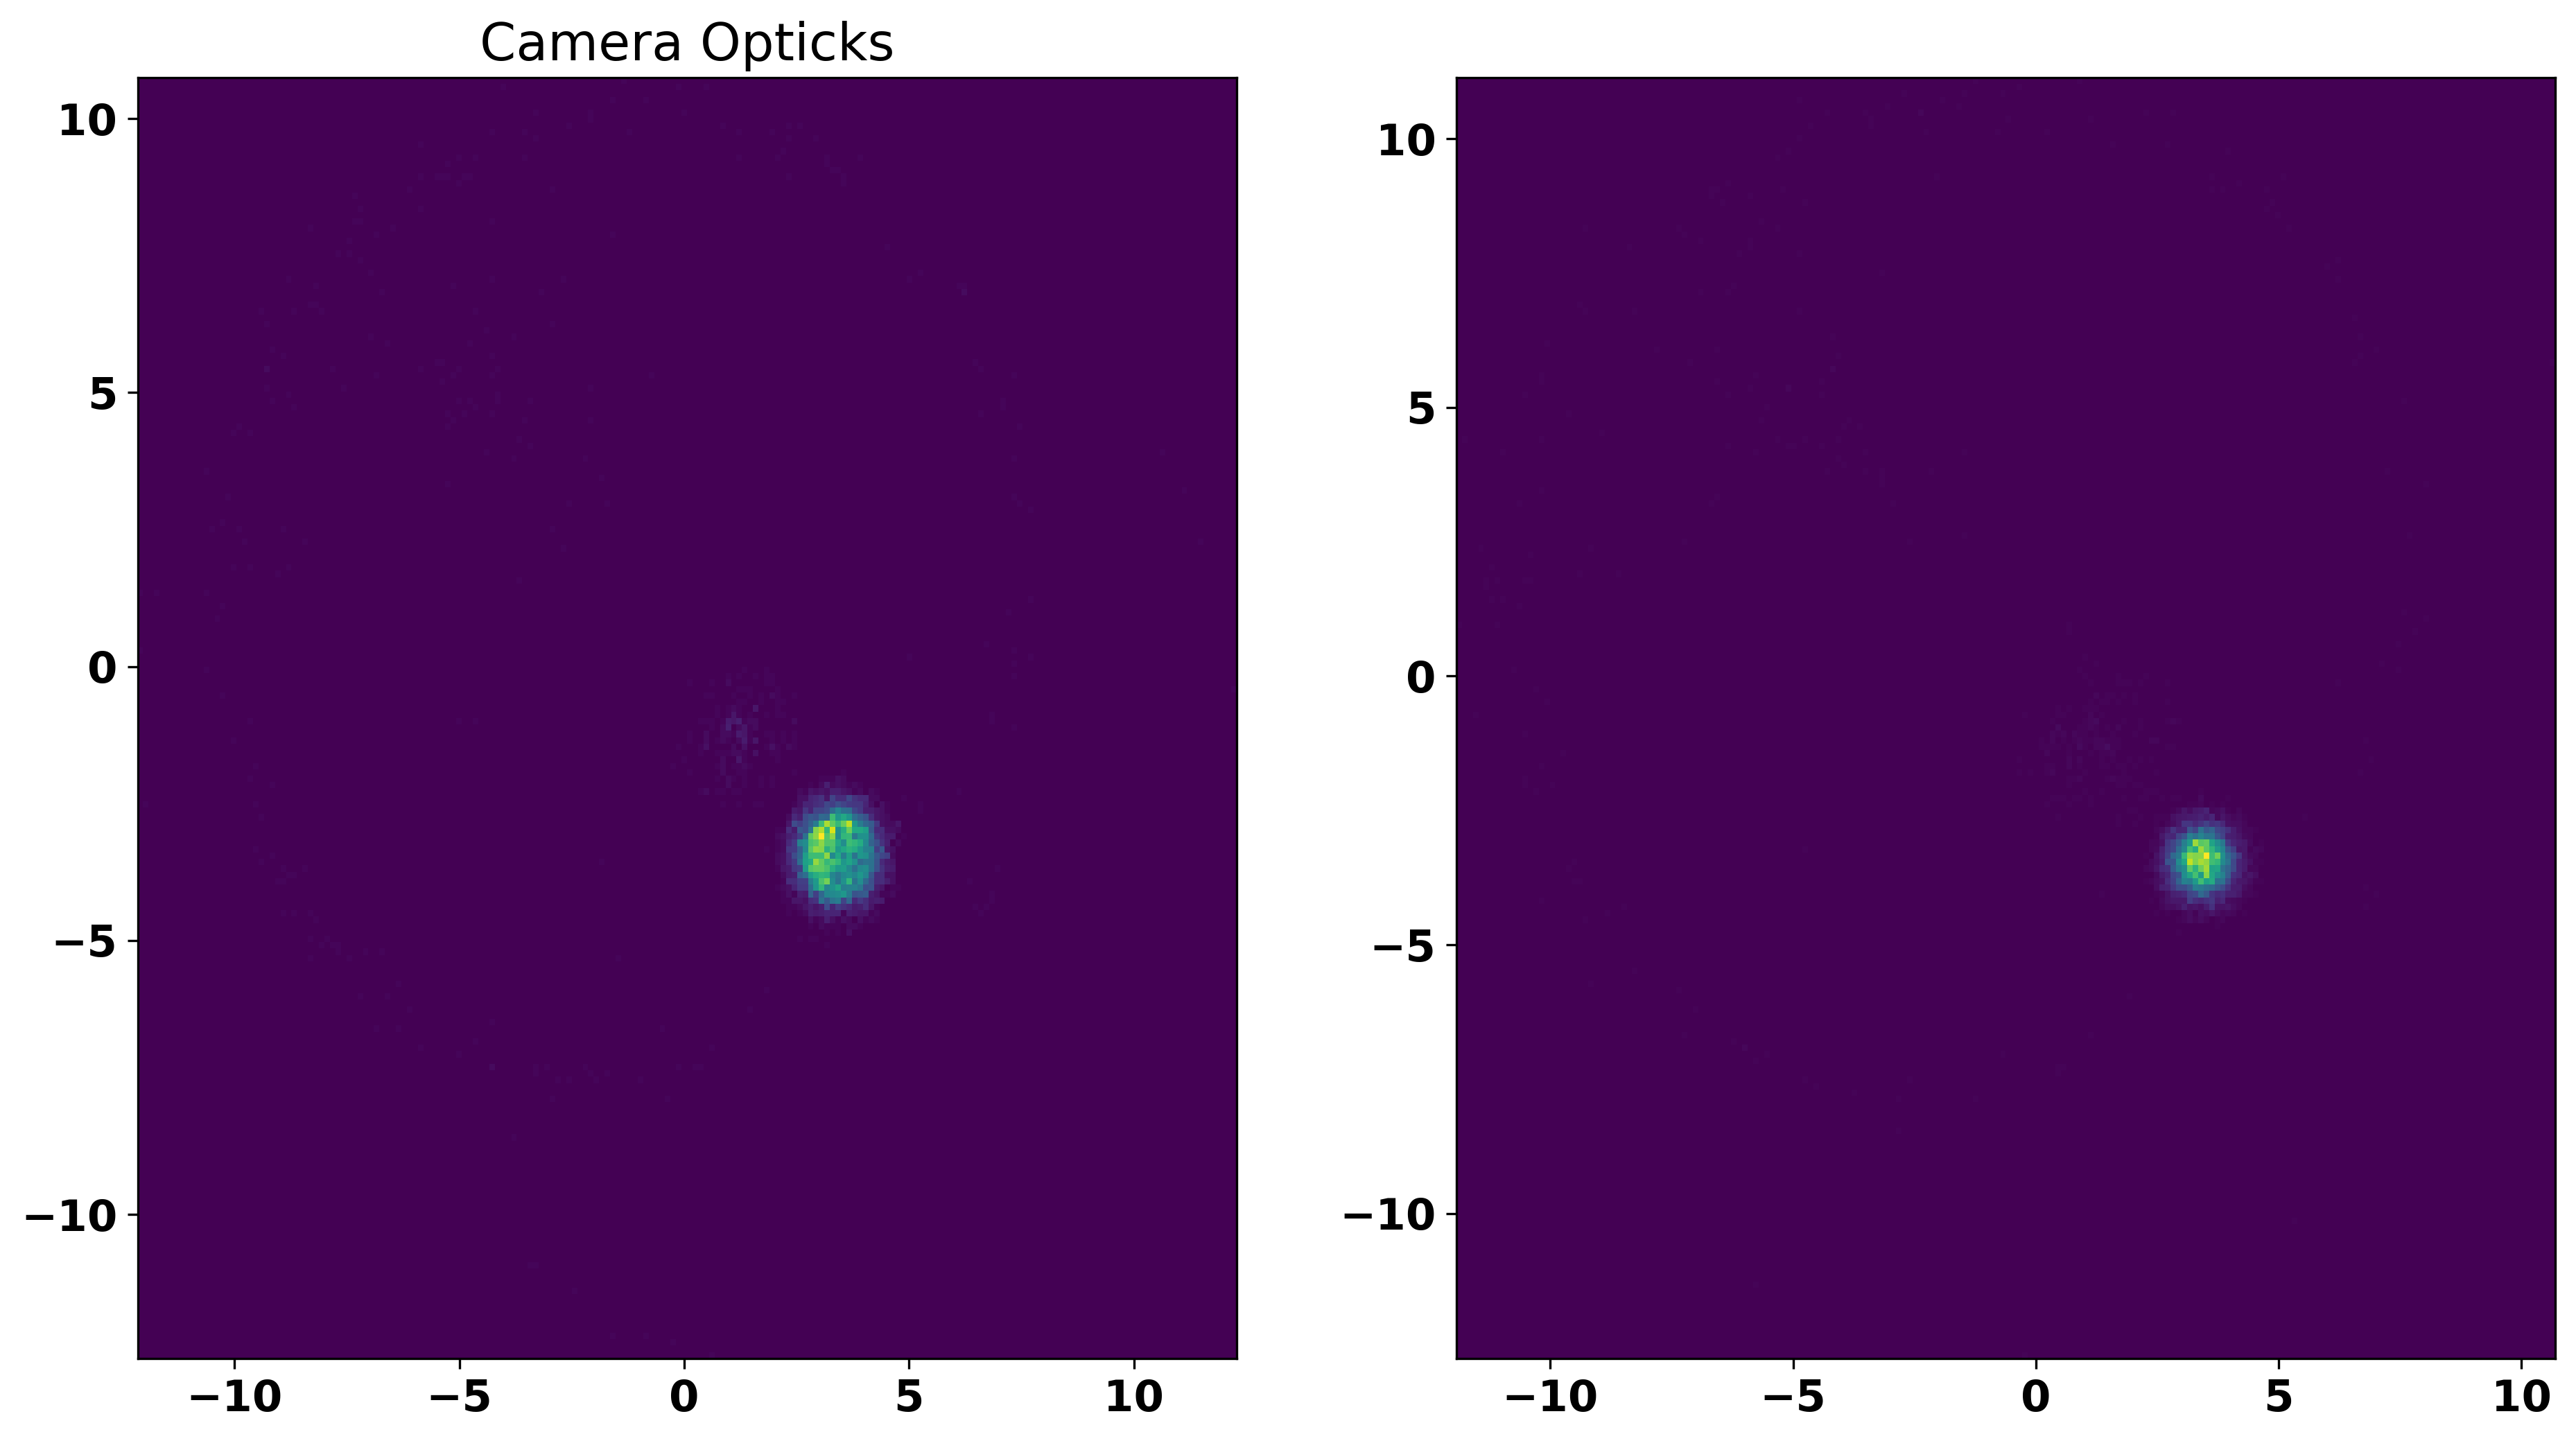

In [24]:
fig,ax=plt.subplots(1,2,dpi=300,figsize=(15,8))
ax[0].set_title("Camera Opticks")
_=ax[0].hist2d(OX,OY,bins=200)
_=ax[1].hist2d(G4X,G4Y,bins=200)

<Figure size 4500x4500 with 0 Axes>

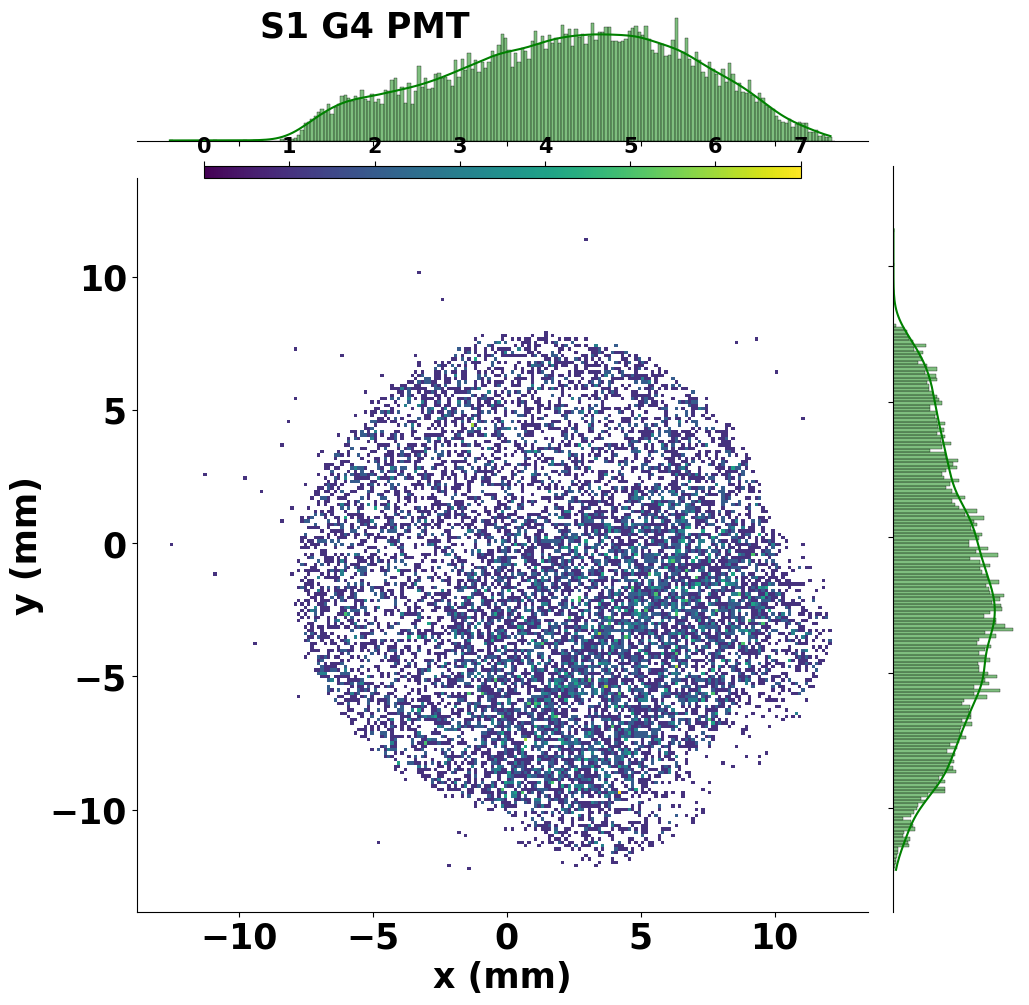

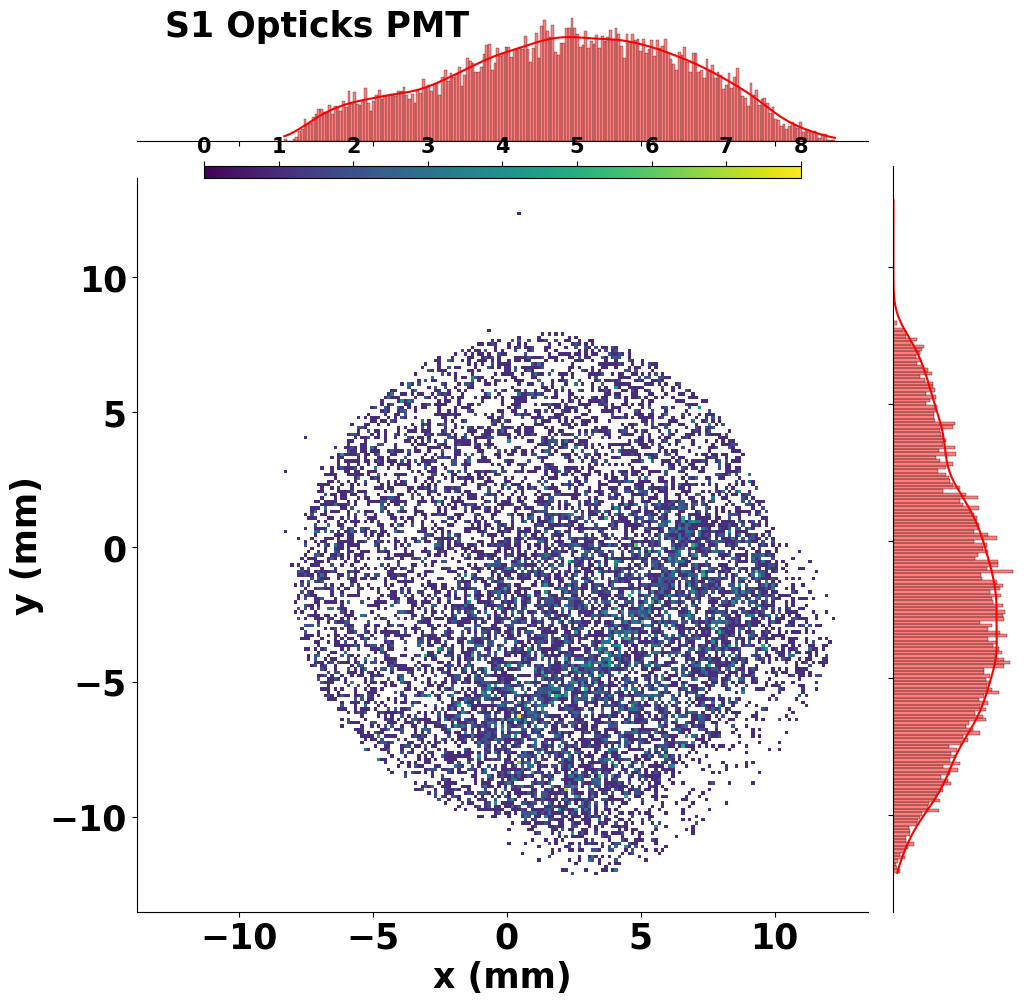

In [25]:
### Get S2 PMT Comparison
G4EventPMTMask=G4Hits["event_id"][G4S1TimeMask][Geant4S1PMTMask] <EventMax
OEventPMTMask=OpticksHits["event_id"][OpticksS1TimeMask][OpticsS1PMTMask] <EventMax
G4X=G4Hits["x"][G4S1TimeMask][Geant4S1PMTMask][G4EventPMTMask]
G4Y=G4Hits["y"][G4S1TimeMask][Geant4S1PMTMask][G4EventPMTMask]
OX=OpticksHits['x'][OpticksS1TimeMask][OpticsS1PMTMask][OEventPMTMask]
OY=OpticksHits['y'][OpticksS1TimeMask][OpticsS1PMTMask][OEventPMTMask]
Plot2D_JointPlot([OX,OY],[G4X,G4Y],["S1_Opticks_PMT_Hits","S1_G4_PMT_Hits"],["S1 Opticks PMT      ","S1 G4 PMT      "],isPlottext=False)

In [26]:
def getHits(Hits,mask1,mask2):
    if(len(mask1) >1 and len(mask2)>1):
        unique, counts = np.unique(Hits['event_id'][mask1][mask2], return_counts=True)
    elif(len(mask1) >1 and len(mask1) <1):
        unique, counts = np.unique(Hits['event_id'][mask1], return_counts=True)
    return counts
def pltHits(O,G4,ax,Labels,Binsize=30,type="both"):
    maXX=np.max(np.array([np.max(G4),np.max(O)]))
    miNX=np.min(np.array([np.min(G4),np.min(O)]))
    lins1X=np.linspace(miNX,maXX,Binsize)
    ax.set_title(Labels,fontweight='bold',fontsize=35)
    h1=ax.hist(G4,bins=lins1X,label=f"G4_"+Labels,color="green",alpha=0.3,edgecolor="green",histtype="step",fill=True)
    
    if(type=="both"):
        try:
            FitHist1D(h1,ax,"","green",0.6)
        except (RuntimeError,TypeError,NameError):
            print(f"Fit issue")
            pass
    lins1X=np.linspace(miNX,maXX,Binsize)    
    h2=ax.hist(O,bins=lins1X,label="Opticks_"+Labels,alpha=0.3,color="red",edgecolor="red",histtype="step",fill=True)
    if(type=="both"):
        try:
            FitHist1D(h2,ax,"","red",0.6)
        except (RuntimeError,TypeError,NameError):
            print(f"Fit issue")
            pass
    ax.set_xlabel("Photons Detected",fontsize=25)
    ax.set_ylabel("Frequency",fontsize=25)
    ax.tick_params(axis='both', which='major', labelsize=25)    

    ax.legend(fontsize=20)
    del h1,h2